## Running GEP scenario files

The cell below uses scenario results from the Global Electrification Platform (GEP) to analyze the competitive price of residue feedstock for a bio-electrification facility.

## Rerun

using NPV residues

In [1]:
#Import dependencies
import os
import pandas as pd
import numpy as np
import numpy_financial as npf

# Util function
from scripts.gep_rerun import *
from scripts.gep_script import *

from scripts.gep_plots import *
pd.options.mode.chained_assignment = None
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
path=os.getcwd()+ '/ng-3-scenarios-results'

fuelCDF = pd.DataFrame() # an empty DataFrame

# Read in excel crop data info
xlsx = pd.ExcelFile(os.getcwd()+ '/Nigeria_crop.xlsx')
top_crop = pd.read_excel(xlsx, 'state')
crop_data = pd.read_excel(xlsx, 'crop')

for scenario_file in os.listdir(path):
    
    if scenario_file.endswith(".csv"):
        
        # Access only csv file present in My Folder
        scenario = scenario_file.split('.')[0]
        
        file = path + f'/{scenario_file}'
        
        print(scenario)
        
        # Run setup
        sub_data = data_setup(file)
        
        # Analyze crop and land
        sub_data = crop_land_calc(sub_data, top_crop, crop_data)

        # Setup Gasifier parameters
        sub_data = gasifier_parameters(sub_data, scenario)

        # Net Present Value (NPV) Investment
        sub_data = npv_investment(sub_data)

        # Net Present Value (NPV) Generation
        sub_data = npv_generation(sub_data)

        # Net Present Value (NPV) Operations and Maintenance
        sub_data = npv_operations(sub_data)
        
        # Net Present Value (NPV) Residue weight
        sub_data = npv_residue(sub_data)
        
        # Delivered Fuel cost (Ft)
        sub_data = npv_fuel_cost_rerun(sub_data)

        # Cumulative distribution of delivered fuel cost
        fuelCDF = fuel_CDF_rerun(sub_data, scenario, fuelCDF)

        # Run post-processing
        data_postprocessing_rerun(sub_data, scenario, fuelCDF)  

ng-3-0_1_0_1_1_0
Length of delivered fuel cost 2
<class 'numpy.ndarray'>
ng-3-0_1_0_0_1_0
Length of delivered fuel cost 33
<class 'numpy.ndarray'>
ng-3-2_0_0_0_1_0
Length of delivered fuel cost 1625
<class 'numpy.ndarray'>
ng-3-2_0_0_1_1_0
Length of delivered fuel cost 39
<class 'numpy.ndarray'>
ng-3-0_0_0_0_1_0
Length of delivered fuel cost 86
<class 'numpy.ndarray'>
ng-3-0_0_0_1_1_0
Length of delivered fuel cost 0
<class 'numpy.ndarray'>


## CDF with NPV Residue

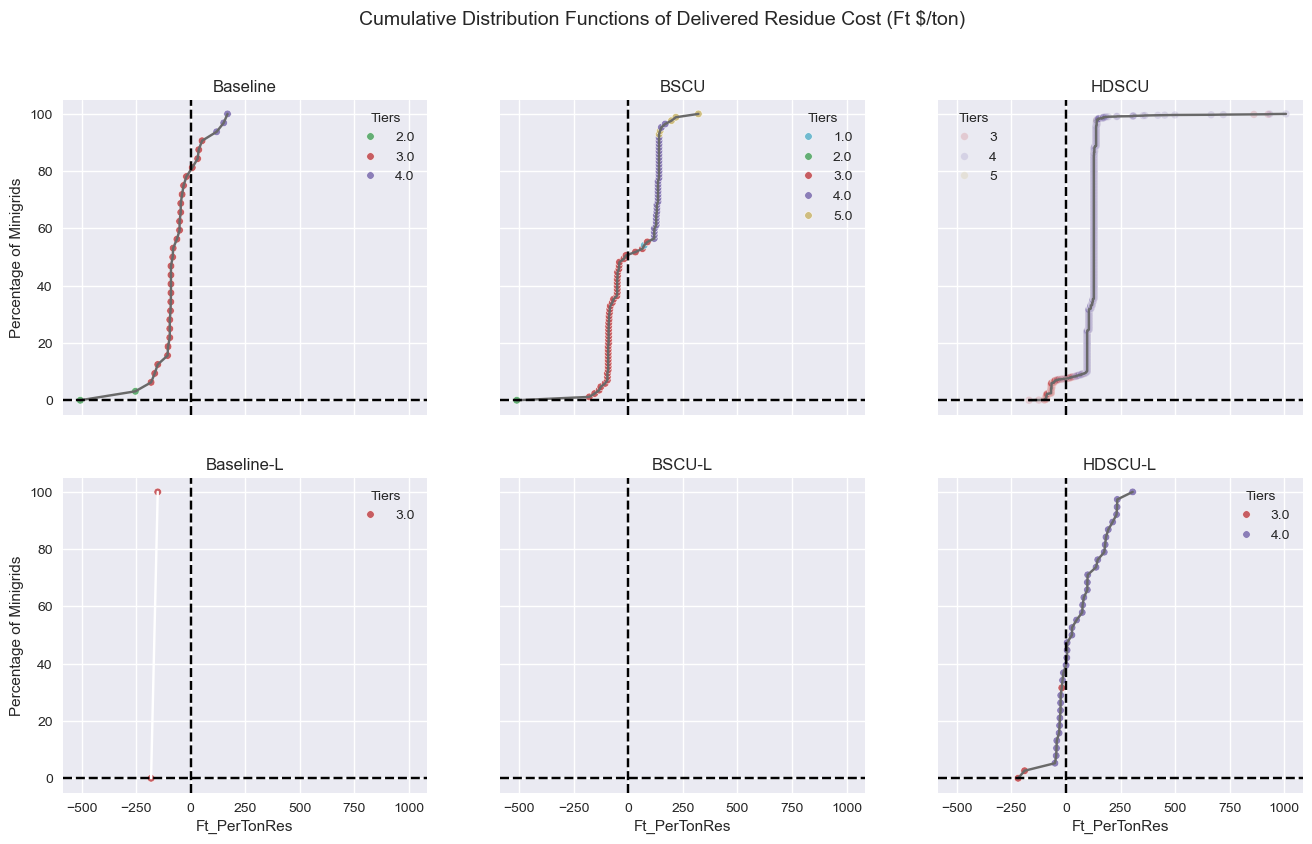

In [18]:
import seaborn as sns
palette ={1: "C5", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}

plt.style.use('seaborn')
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('CDF.csv')
cdfCol = df.columns
figure, axis = plt.subplots(2, 3, figsize=(16,9),sharey=True, sharex=True)

sns.lineplot(data=df, x='ng-3-0_0_0_0_1_0',y='ng-3-0_0_0_0_1_0-cum', ax= axis[0,1], color='dimgrey')
sns.scatterplot(data=df, x='ng-3-0_0_0_0_1_0', y='ng-3-0_0_0_0_1_0-cum', s=30, alpha=0.9, hue='ng-3-0_0_0_0_1_0-tier', ax=axis[0,1], palette=palette)
axis[0,1].set(title='BSCU')
axis[0,1].axvline(0, c='black', ls='--') 
axis[0,1].axhline(0, c='black', ls='--')
axis[0,1].get_legend().set_visible(True)
axis[0,1].legend(title='Tiers')
axis[0,1].set(xlabel=None)

sns.lineplot(data=df, x='ng-3-0_0_0_1_1_0',y='ng-3-0_0_0_1_1_0-cum', ax= axis[1,1], color='dimgrey')
sns.scatterplot(data=df, x='ng-3-0_0_0_1_1_0', y='ng-3-0_0_0_1_1_0-cum', s=30, alpha=0.9, ax=axis[1,1])
axis[1,1].set(title='BSCU-L')
axis[1,1].axvline(0, c='black', ls='--') 
axis[1,1].axhline(0, c='black', ls='--') 
# axis[1,1].get_legend().set_visible(True)
# axis[1,1].legend(title='Tiers')
# axis[1,1].set(xlabel=None)

sns.lineplot(data=df, x='ng-3-0_1_0_0_1_0',y='ng-3-0_1_0_0_1_0-cum', ax= axis[0,0], color='dimgrey')
sns.scatterplot(data=df, x='ng-3-0_1_0_0_1_0', y='ng-3-0_1_0_0_1_0-cum', s=30, alpha=0.9, hue='ng-3-0_1_0_0_1_0-tier', ax=axis[0,0],palette=palette)
axis[0,0].set(title='Baseline')
axis[0,0].axvline(0, c='black', ls='--') 
axis[0,0].axhline(0, c='black', ls='--')
# axis[0,0].get_legend().set_visible(True)
axis[0,0].legend(title='Tiers')
axis[0,0].set(xlabel=None)

sns.lineplot(data=df, x='ng-3-0_1_0_1_1_0', y='ng-3-0_1_0_1_1_0-cum', ax= axis[1,0], color='white')
sns.scatterplot(data=df, x='ng-3-0_1_0_1_1_0', y='ng-3-0_1_0_1_1_0-cum', s=30, alpha=0.9, hue='ng-3-0_1_0_1_1_0-tier', ax=axis[1,0],palette=palette)
axis[1,0].set(title='Baseline-L')
axis[1,0].axvline(0, c='black', ls='--') 
axis[1,0].axhline(0, c='black', ls='--')
axis[1,0].get_legend().set_visible(True)
axis[1,0].legend(title='Tiers')
axis[1,0].set(xlabel=None)

sns.lineplot(data=df, x='ng-3-2_0_0_0_1_0',y='ng-3-2_0_0_0_1_0-cum', ax= axis[0,2], color='dimgrey')
sns.scatterplot(data=df, x='ng-3-2_0_0_0_1_0', y='ng-3-2_0_0_0_1_0-cum', s=30, alpha=0.2, hue='ng-3-2_0_0_0_1_0-tier', ax=axis[0,2],palette=palette)
axis[0,2].set(title='HDSCU')
axis[0,2].axvline(0, c='black', ls='--') 
axis[0,2].axhline(0, c='black', ls='--')
axis[0,2].get_legend().set_visible(True)
axis[0,2].legend(title='Tiers')
axis[0,2].set(xlabel=None)

sns.lineplot(data=df, x='ng-3-2_0_0_1_1_0',y='ng-3-2_0_0_1_1_0-cum', ax= axis[1,2], color='dimgrey')
sns.scatterplot(data=df, x='ng-3-2_0_0_1_1_0', y='ng-3-2_0_0_1_1_0-cum', s=30, alpha=0.9, hue='ng-3-2_0_0_1_1_0-tier', ax=axis[1,2],palette=palette)
axis[1,2].set(title='HDSCU-L')
axis[1,2].axvline(0, c='black', ls='--') 
axis[1,2].axhline(0, c='black', ls='--')
axis[1,2].get_legend().set_visible(True)
axis[1,2].legend(title='Tiers')
axis[1,2].set(xlabel=None)

    
figure.suptitle('Cumulative Distribution Functions of Delivered Residue Cost (Ft $/ton)', fontsize=14)
#figure.supxlabel('Ft_PerTonRes', fontsize= 14)
#figure.supylabel('Percentage of Minigrids', fontsize=14)

'''
lines = [] 
labels = []

#set legend
for ax in figure.axes: 
    Line, Label = ax.get_legend_handles_labels() 
    print(Label)
    lines.extend(Line) 
    labels.extend(Label) 


figure.legend(lines, labels, loc='upper right') 
'''
sns.despine()
plt.setp(axis[-1, :], xlabel='Ft_PerTonRes')
plt.setp(axis[:, 0], ylabel='Percentage of Minigrids')
plt.show()